# Round 2: SVM with SMOTE (Full Reporting)

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set(style='whitegrid')
reports_dir = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/reports'
os.makedirs(reports_dir, exist_ok=True)


In [ ]:

train_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/train.xlsx')
val_df = pd.read_excel('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/val.xlsx')

# Ensure string type
X_train = train_df['cleaned_poem'].astype(str)
X_val = val_df['cleaned_poem'].astype(str)

y_train_p = train_df['primary_id']
y_val_p = val_df['primary_id']
y_train_s = train_df['secondary_id']
y_val_s = val_df['secondary_id']

# Map is {'Label': ID}, we want {ID: 'Label'}
with open('/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round2/label_maps.json', 'r') as f:
    maps = json.load(f)

# Correct logic: k=Label (str), v=ID (int). We want {v: k}
p_map = {v: k for k, v in maps['primary_map'].items()}
s_map = {v: k for k, v in maps['secondary_map'].items()}


In [ ]:

def evaluate_full(y_true, y_pred, label_map, prefix):
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec_w = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    print(f"\n--- Report for {prefix} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {prec_w:.4f}")
    print(f"Weighted Recall: {rec_w:.4f}")
    print(f"Weighted F1: {f1_w:.4f}")
    
    # Save Metrics
    with open(f'{reports_dir}/{prefix}_metrics.json', 'w') as f:
        json.dump({
            'accuracy': acc, 'weighted_precision': prec_w, 
            'weighted_recall': rec_w, 'weighted_f1': f1_w
        }, f, indent=4)
        
    # Class-wise Report
    class_report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    # Convert report keys (which are strings of IDs '0', '1'...) to Labels
    if label_map:
        new_report = {}
        for k, v in class_report.items():
            if k.isdigit():
                label_name = label_map.get(int(k), k)
                new_report[label_name] = v
            else:
                new_report[k] = v
        class_report = new_report
        
    pd.DataFrame(class_report).transpose().to_csv(f'{reports_dir}/{prefix}_class_report.csv')
    print("Class-wise report saved.")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues', fmt='d')
    plt.title(f'{prefix} Confusion Matrix')
    plt.savefig(f'{reports_dir}/{prefix}_confusion_matrix.png')
    plt.show()


In [ ]:

def plot_learning_curve_graph(estimator, title, X, y, cv=3, n_jobs=1):
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    # robustly handle errors (e.g. SMOTE failing on small samples) by returning NaN
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        scoring='accuracy',
        error_score=np.nan
    )
    
    # Use nanmean/nanstd to ignore failures
    train_scores_mean = np.nanmean(train_scores, axis=1)
    train_scores_std = np.nanstd(train_scores, axis=1)
    test_scores_mean = np.nanmean(test_scores, axis=1)
    test_scores_std = np.nanstd(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    plt.savefig(f'{reports_dir}/{title.replace(" ", "_")}_learning_curve.png')
    plt.show()


In [ ]:

def visualize_features(pipeline, title, top_n=20):
    # Try to extract vectorizer and model
    try:
        if 'tfidf' in pipeline.named_steps:
            vect = pipeline.named_steps['tfidf']
            feature_names = np.array(vect.get_feature_names_out())
            
            model = None
            if 'clf' in pipeline.named_steps: model = pipeline.named_steps['clf']
            elif 'rf' in pipeline.named_steps: model = pipeline.named_steps['rf']
            elif 'svm' in pipeline.named_steps: model = pipeline.named_steps['svm']
            elif 'lr' in pipeline.named_steps: model = pipeline.named_steps['lr']
            elif 'nb' in pipeline.named_steps: model = pipeline.named_steps['nb']
            
            if hasattr(model, 'coef_'):
                # For linear models (SVM, LR, NB) - Average absolute coef across classes if multi-class
                if model.coef_.ndim > 1:
                    coefs = np.mean(np.abs(model.coef_), axis=0)
                else:
                    coefs = np.abs(model.coef_)
            elif hasattr(model, 'feature_importances_'):
                # For Tree models
                coefs = model.feature_importances_
            else:
                print(f"Model {title} does not expose coefficients or feature importances.")
                return

            # Sort
            indices = np.argsort(coefs)[-top_n:]
            plt.figure(figsize=(10, 8))
            plt.title(f'Top {top_n} Features for {title}')
            plt.barh(range(len(indices)), coefs[indices], color='b', align='center')
            plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
            plt.xlabel('Importance/Weight')
            plt.tight_layout()
            plt.savefig(f'{reports_dir}/{title.replace(" ", "_")}_features.png')
            plt.show()
            
    except Exception as e:
        print(f"Could not visualize features for {title}: {e}")


Training SMOTE SVM svm_smote_primary...

--- Report for svm_smote_primary ---
Accuracy: 0.4036
Weighted Precision: 0.3870
Weighted Recall: 0.4036
Weighted F1: 0.3890
Class-wise report saved.


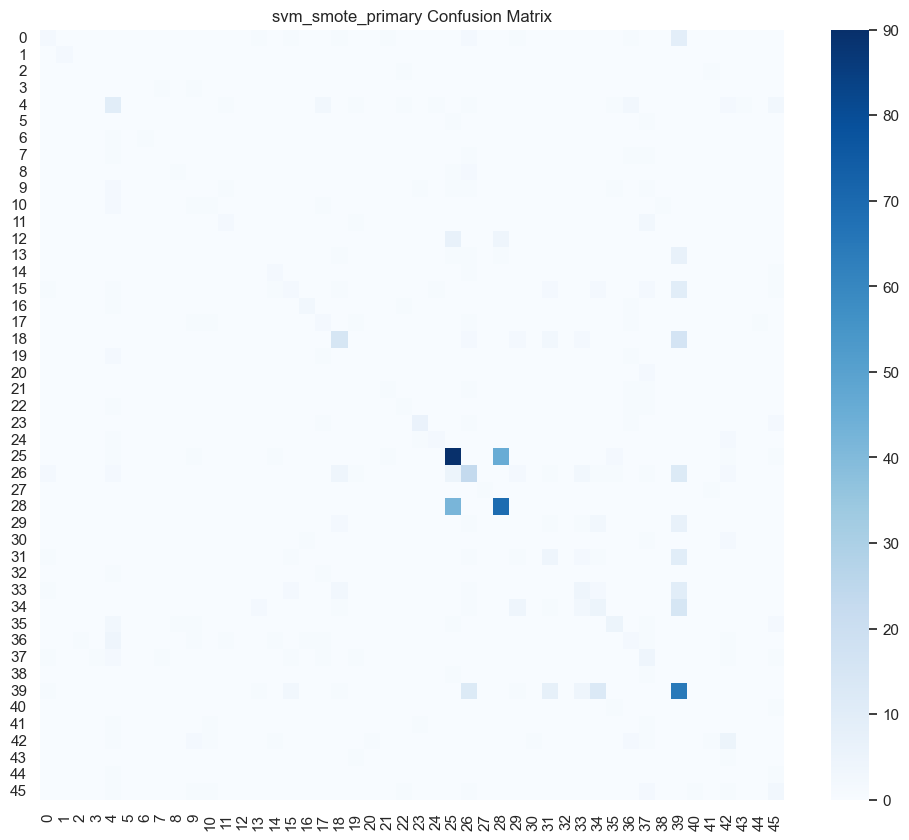

/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Glyph 2951 (\N{TAMIL LETTER I}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Glyph 2985 (\N{TAMIL LETTER NNNA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Glyph 3021 (\N{TAMIL SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_28443/2096954843.py:35: UserWarning: Glyph 3006 (\N{TAM

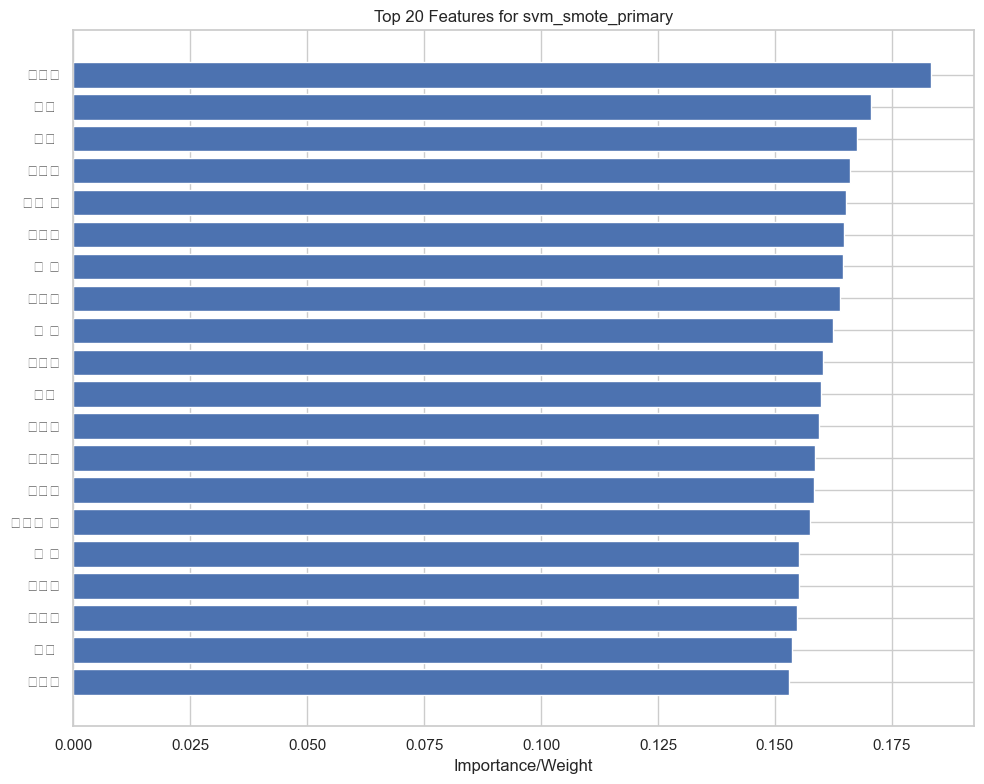

ValueError: 
All the 15 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/main_nlp_env/lib/python3.11/site-packages/imblearn/pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/

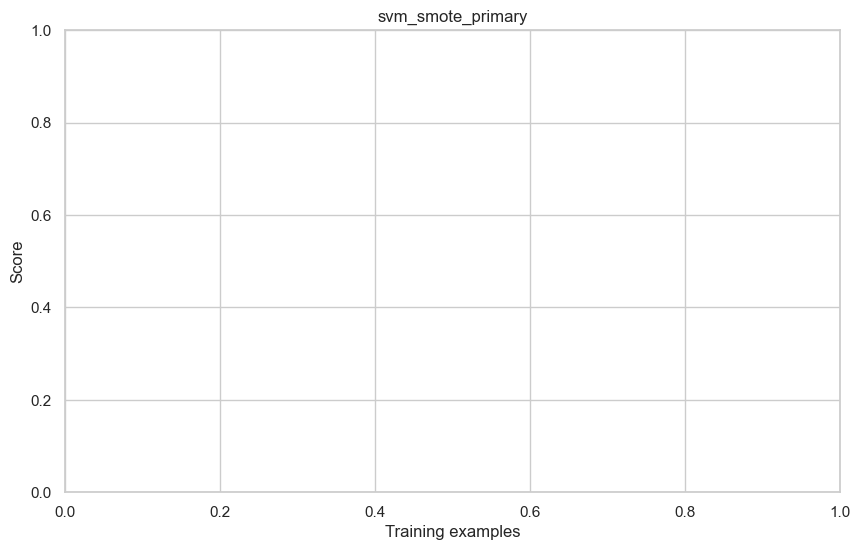

In [ ]:
def train_smote(X, y, name):
    print(f'Training SMOTE SVM {name}...')
    pipeline = ImbPipeline([
        ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5, sublinear_tf=True)),
        ('smote', SMOTE(random_state=42, k_neighbors=1)),  # Use k_neighbors=1 for small classes
        ('svm', LinearSVC(class_weight='balanced', random_state=42))
    ])
    pipeline.fit(X, y)
    y_pred = pipeline.predict(X_val)
    evaluate_full(y_val_p if 'primary' in name else y_val_s, y_pred, p_map if 'primary' in name else s_map, name)
    visualize_features(pipeline, name)
    
    # Learning curve can fail with SMOTE on small class splits - handle gracefully
    try:
        plot_learning_curve_graph(pipeline, name, X, y, cv=3, n_jobs=1)
    except ValueError as e:
        print(f"Skipping learning curve for {name} due to small class sizes: {e}")

train_smote(X_train, y_train_p, 'svm_smote_primary')
train_smote(X_train, y_train_s, 'svm_smote_secondary')